# PCA — Weekend Gap Prediction

**Goal:** Test whether projecting features into a lower-dimensional orthogonal space improves classification performance for Logistic Regression and XGBoost.

**Two PCA strategies compared:**
- **Per-fold PCA** — fitted on each training fold only; no leakage into the test set
- **Global PCA** — fitted once on the full dataset; mild future leakage, included as an upper bound

**Two validation strategies compared:**
- **Year-based folds** — 6 folds, expanding window 2016–2024, identical to `logistic_regression.ipynb`
- **TimeSeriesSplit(n=18)** — 18 folds, finer granularity, index-based

**Research question:** Does decorrelating and compressing the feature space improve or hurt predictive accuracy?

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

## 1. Load Data & Define Feature Set

In [86]:
df_all = pd.read_csv('../structured_csv_data_files/fetched_data/dataset_clean.csv')
df_all['Date'] = pd.to_datetime(df_all['Date'])

primary = df_all[df_all['is_extreme_event'] == 0].copy().reset_index(drop=True)
extreme = df_all[df_all['is_extreme_event'] == 1].copy().reset_index(drop=True)

# Sort by date — required for TimeSeriesSplit to slice chronologically
primary = primary.sort_values('Date').reset_index(drop=True)

print(f'Primary dataset: {len(primary):,} rows   GapUp rate: {primary["GapUp"].mean():.3f}')
print(f'Extreme events:  {len(extreme):,} rows   GapUp rate: {extreme["GapUp"].mean():.3f}')

Primary dataset: 8,146 rows   GapUp rate: 0.516
Extreme events:  291 rows   GapUp rate: 0.450


In [87]:
MOMENTUM    = ['MACD', 'ROC', 'StochPercK']
TREND       = ['CloseVEma50', 'CloseVSma20', 'ADX']
VOLATILITY  = ['BollingerBandWidth', 'ATR', 'FiveDStdDev']
VOLUME      = ['OBV', 'MFI', 'VolumeRatio']
FUNDAMENTAL = ['NetMargin', 'RoA', 'RevGrowthQoQ']
MISS_IND    = ['GrossMargin_missing', 'CostOfRevenues_missing', 'Liabilities_missing']

FEATURES = MOMENTUM + TREND + VOLATILITY + VOLUME + FUNDAMENTAL + MISS_IND
TARGET   = 'GapUp'

X_all       = primary[FEATURES].reset_index(drop=True)
y_all       = primary[TARGET].reset_index(drop=True)
tickers_all = primary['Ticker'].reset_index(drop=True)
dates_all   = primary['Date'].reset_index(drop=True)

print(f'Features: {len(FEATURES)}   Rows: {len(X_all):,}')
print(f'Date range: {dates_all.min().date()} to {dates_all.max().date()}')

Features: 18   Rows: 8,146
Date range: 2016-04-18 to 2024-12-23


## 2. Preprocessing

Same pipeline as `logistic_regression.ipynb` — fitted on training fold only, applied to test.

- **OBV** — per-ticker z-score (removes cumulative scale, keeps direction)
- **ATR, BollingerBandWidth, FiveDStdDev, VolumeRatio** — log1p then StandardScalerScaler
- **All others** — StandardScaler only
- **Missingness indicators** — no scaling (already binary)

In [88]:
LOG1P_FEATURES    = ['ATR', 'BollingerBandWidth', 'FiveDStdDev', 'VolumeRatio']
OBV_FEATURE       = ['OBV']
BINARY_FEATURES   = MISS_IND

def preprocess(X_train, X_test, train_tickers, test_tickers):
    X_tr, X_te = X_train.copy(), X_test.copy()
    obv_stats = X_tr.assign(Ticker=train_tickers.values).groupby('Ticker')['OBV'].agg(['mean','std'])
    for df_x, tickers in [(X_tr, train_tickers), (X_te, test_tickers)]:
        means = tickers.map(obv_stats['mean']).fillna(obv_stats['mean'].mean())
        stds  = tickers.map(obv_stats['std']).fillna(obv_stats['std'].mean()).replace(0, 1)
        df_x['OBV'] = (df_x['OBV'].values - means.values) / stds.values
    for col in LOG1P_FEATURES:
        X_tr[col] = np.log1p(X_tr[col].clip(lower=0))
        X_te[col] = np.log1p(X_te[col].clip(lower=0))
    cols_to_scale = [f for f in FEATURES if f not in BINARY_FEATURES]
    scaler = StandardScaler()
    X_tr[cols_to_scale] = scaler.fit_transform(X_tr[cols_to_scale])
    X_te[cols_to_scale] = scaler.transform(X_te[cols_to_scale])
    return X_tr.values, X_te.values


def global_preprocess(X, tickers):
    """Same transforms as preprocess() but fitted on the full dataset.
    Used only for the global PCA experiment."""
    X_proc = X.copy()
    obv_stats = X_proc.assign(Ticker=tickers.values).groupby('Ticker')['OBV'].agg(['mean','std'])
    means = tickers.map(obv_stats['mean']).fillna(obv_stats['mean'].mean())
    stds  = tickers.map(obv_stats['std']).fillna(obv_stats['std'].mean()).replace(0, 1)
    X_proc['OBV'] = (X_proc['OBV'].values - means.values) / stds.values
    for col in LOG1P_FEATURES:
        X_proc[col] = np.log1p(X_proc[col].clip(lower=0))
    cols_to_scale = [f for f in FEATURES if f not in BINARY_FEATURES]
    scaler = StandardScaler()
    X_proc[cols_to_scale] = scaler.fit_transform(X_proc[cols_to_scale])
    return X_proc.values


print('preprocess()        — fitted on each training fold (used everywhere except global PCA)')
print('global_preprocess() — fitted on full dataset     (used only for global PCA section)')

preprocess()        — fitted on each training fold (used everywhere except global PCA)
global_preprocess() — fitted on full dataset     (used only for global PCA section)


## 3. Walk-Forward Fold Setup

**Year-based folds** — expanding window, identical to `logistic_regression.ipynb`:

| Test year | Training years |
|---|---|
| 2019 | 2016–2018 |
| 2020 | 2016–2019 |
| 2021 | 2016–2020 |
| 2022 | 2016–2021 |
| 2023 | 2016–2022 |
| 2024 | 2016–2023 |

**TimeSeriesSplit(n=18)** — divides the date-sorted dataset into 18 equal-row blocks. Finer granularity than year-based folds but boundaries are index-based, not calendar-aligned.

In [89]:
# ── Year-based folds (identical to logistic_regression.ipynb) ─────────────
FOLDS_DEF = [
    {'train_years': list(range(2016, 2019)), 'test_year': 2019},
    {'train_years': list(range(2016, 2020)), 'test_year': 2020},
    {'train_years': list(range(2016, 2021)), 'test_year': 2021},
    {'train_years': list(range(2016, 2022)), 'test_year': 2022},
    {'train_years': list(range(2016, 2023)), 'test_year': 2023},
    {'train_years': list(range(2016, 2024)), 'test_year': 2024},
]

year_folds = []
for fold in FOLDS_DEF:
    tr_idx = np.where(primary['Year'].isin(fold['train_years']))[0]
    te_idx = np.where(primary['Year'] == fold['test_year'])[0]
    year_folds.append((tr_idx, te_idx))

print('Year-based folds (same as logistic_regression.ipynb):')
for i, ((tr, te), fd) in enumerate(zip(year_folds, FOLDS_DEF), 1):
    print(f'  Fold {i} | Train: {len(tr):,} | Test: {len(te):,} | Test year: {fd["test_year"]}')

# ── TimeSeriesSplit(n_splits=18) ───────────────────────────────────────────
tscv       = TimeSeriesSplit(n_splits=18)
tscv_folds = list(tscv.split(X_all))

print()
print('TimeSeriesSplit(n_splits=18):')
for i, (tr, te) in enumerate(tscv_folds, 1):
    ts = dates_all.iloc[te[0]].date()
    te_d = dates_all.iloc[te[-1]].date()
    print(f'  Fold {i:2d} | Train: {len(tr):,} | Test: {len(te):,} | {ts} -> {te_d}')

Year-based folds (same as logistic_regression.ipynb):
  Fold 1 | Train: 2,682 | Test: 992 | Test year: 2019
  Fold 2 | Train: 3,674 | Test: 613 | Test year: 2020
  Fold 3 | Train: 4,287 | Test: 917 | Test year: 2021
  Fold 4 | Train: 5,204 | Test: 997 | Test year: 2022
  Fold 5 | Train: 6,201 | Test: 953 | Test year: 2023
  Fold 6 | Train: 7,154 | Test: 992 | Test year: 2024

TimeSeriesSplit(n_splits=18):
  Fold  1 | Train: 442 | Test: 428 | 2016-09-26 -> 2017-03-06
  Fold  2 | Train: 870 | Test: 428 | 2017-03-06 -> 2017-08-07
  Fold  3 | Train: 1,298 | Test: 428 | 2017-08-07 -> 2018-01-22
  Fold  4 | Train: 1,726 | Test: 428 | 2018-01-22 -> 2018-07-16
  Fold  5 | Train: 2,154 | Test: 428 | 2018-07-16 -> 2018-12-03
  Fold  6 | Train: 2,582 | Test: 428 | 2018-12-10 -> 2019-05-20
  Fold  7 | Train: 3,010 | Test: 428 | 2019-05-20 -> 2019-10-21
  Fold  8 | Train: 3,438 | Test: 428 | 2019-10-21 -> 2020-07-27
  Fold  9 | Train: 3,866 | Test: 428 | 2020-07-27 -> 2021-01-11
  Fold 10 | Train: 

## 4. Baseline — No PCA

Logistic Regression with L1 regularisation, C tuned per fold via inner-val AUC — identical setup to `logistic_regression.ipynb`.

Averages exclude the COVID fold (test 2020) to match `logistic_regression.ipynb`'s primary evaluation. tscv(18) has no year labels so it averages all folds.

In [90]:
C_GRID = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]

def run_baseline(folds_def):
    """C tuned per fold via inner-val AUC. Returns (fold_accs, fold_aucs, test_years)."""
    fold_accs, fold_aucs, fold_years = [], [], []
    for fold in folds_def:
        train_years = fold['train_years']
        test_year   = fold['test_year']
        val_year    = train_years[-1]
        inner_train = [y for y in train_years if y != val_year]

        tr_idx  = np.where(primary['Year'].isin(train_years))[0]
        te_idx  = np.where(primary['Year'] == test_year)[0]
        itr_idx = np.where(primary['Year'].isin(inner_train))[0]
        iv_idx  = np.where(primary['Year'] == val_year)[0]

        X_tr_s, X_te_s  = preprocess(X_all.iloc[tr_idx],  X_all.iloc[te_idx],
                                      tickers_all.iloc[tr_idx],  tickers_all.iloc[te_idx])
        X_itr_s, X_iv_s = preprocess(X_all.iloc[itr_idx], X_all.iloc[iv_idx],
                                      tickers_all.iloc[itr_idx], tickers_all.iloc[iv_idx])

        best_c, best_iv_auc = C_GRID[0], -np.inf
        for c in C_GRID:
            m = LogisticRegression(penalty='l1', solver='liblinear', C=c,
                                   max_iter=1000, random_state=42)
            m.fit(X_itr_s, y_all.iloc[itr_idx])
            a = roc_auc_score(y_all.iloc[iv_idx], m.predict_proba(X_iv_s)[:, 1])
            if a > best_iv_auc:
                best_iv_auc, best_c = a, c

        model = LogisticRegression(penalty='l1', solver='liblinear', C=best_c,
                                   max_iter=1000, random_state=42)
        model.fit(X_tr_s, y_all.iloc[tr_idx])
        y_pred = model.predict(X_te_s)
        y_prob = model.predict_proba(X_te_s)[:, 1]
        fold_accs.append(accuracy_score(y_all.iloc[te_idx], y_pred))
        fold_aucs.append(roc_auc_score(y_all.iloc[te_idx], y_prob))
        fold_years.append(test_year)

    return fold_accs, fold_aucs, fold_years


# Year folds — exclude COVID (2020) to match logistic_regression.ipynb primary evaluation
yr_accs, yr_aucs, yr_years = run_baseline(FOLDS_DEF)
nc_idx      = [i for i, yr in enumerate(yr_years) if yr != 2020]
bl_acc_year = np.mean([yr_accs[i] for i in nc_idx])
bl_auc_year = np.mean([yr_aucs[i] for i in nc_idx])

# tscv: index-based, no year labels — fixed C=0.05, all-fold average
bl_acc_tscv_raw, bl_auc_tscv_raw = 0.0, 0.0
for train_idx, test_idx in tscv_folds:
    X_tr_s, X_te_s = preprocess(X_all.iloc[train_idx], X_all.iloc[test_idx],
                                 tickers_all.iloc[train_idx], tickers_all.iloc[test_idx])
    m = LogisticRegression(penalty='l1', solver='liblinear', C=0.05,
                           max_iter=1000, random_state=42)
    m.fit(X_tr_s, y_all.iloc[train_idx])
    bl_acc_tscv_raw += accuracy_score(y_all.iloc[test_idx], m.predict(X_te_s))
    bl_auc_tscv_raw += roc_auc_score(y_all.iloc[test_idx],
                                      m.predict_proba(X_te_s)[:, 1])
bl_acc_tscv = bl_acc_tscv_raw / len(tscv_folds)
bl_auc_tscv = bl_auc_tscv_raw / len(tscv_folds)

print(f'Baseline — Year folds (non-COVID avg): Acc={bl_acc_year:.4f}  AUC={bl_auc_year:.4f}')
print(f'Baseline — tscv(18)                  : Acc={bl_acc_tscv:.4f}  AUC={bl_auc_tscv:.4f}')

Baseline — Year folds (non-COVID avg): Acc=0.5523  AUC=0.5736
Baseline — tscv(18)                  : Acc=0.5580  AUC=0.5786


## 5. Explained Variance Analysis

Fitted on the last year-based fold's training data (2016–2023) for visualisation only — not used for selection. Shows the minimum k needed to retain 90% and 95% of total variance.

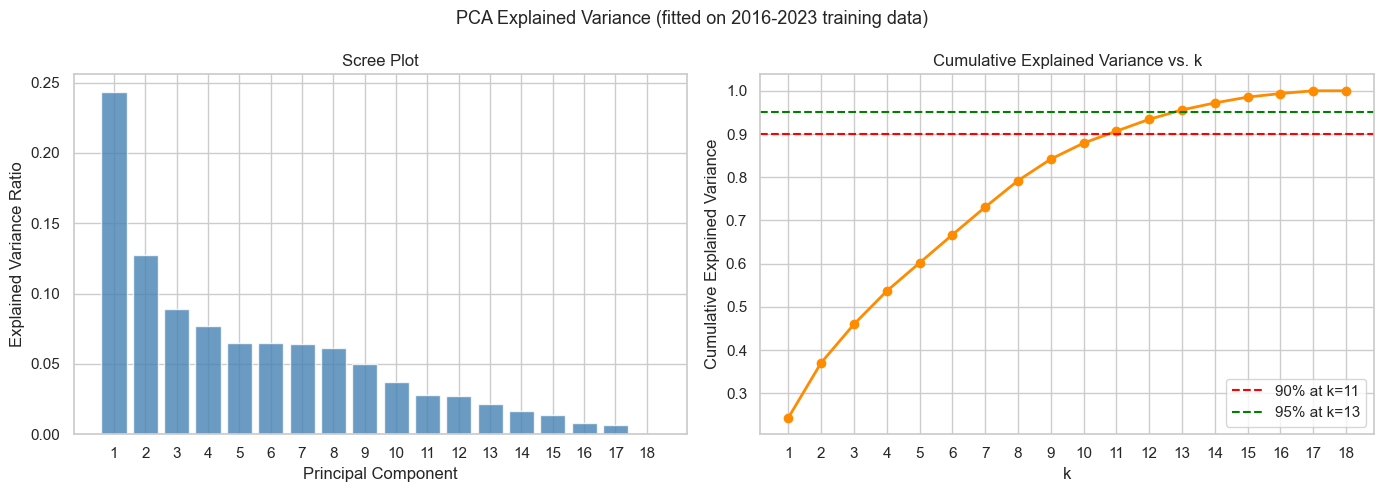

90% variance at k=11,  95% variance at k=13


In [91]:
last_tr_yr, last_te_yr = year_folds[-1]
X_vis_tr, _ = preprocess(
    X_all.iloc[last_tr_yr], X_all.iloc[last_te_yr],
    tickers_all.iloc[last_tr_yr], tickers_all.iloc[last_te_yr]
)

pca_full       = PCA(n_components=len(FEATURES)).fit(X_vis_tr)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = int(np.argmax(cumulative_var >= 0.90) + 1)
n_95 = int(np.argmax(cumulative_var >= 0.95) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(FEATURES)+1), pca_full.explained_variance_ratio_,
            color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, len(FEATURES)+1))

axes[1].plot(range(1, len(FEATURES)+1), cumulative_var, 'o-', color='darkorange', linewidth=2)
axes[1].axhline(0.90, color='red',   linestyle='--', label=f'90% at k={n_90}')
axes[1].axhline(0.95, color='green', linestyle='--', label=f'95% at k={n_95}')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance vs. k')
axes[1].set_xticks(range(1, len(FEATURES)+1))
axes[1].legend()

plt.suptitle('PCA Explained Variance (fitted on 2016-2023 training data)', fontsize=13)
plt.tight_layout()
plt.show()
print(f'90% variance at k={n_90},  95% variance at k={n_95}')

## 6. Per-Fold PCA — Logistic Regression

For each k, PCA is fitted on each training fold only (no leakage), then Logistic Regression is run. Sweep covers all k from 1 to the full feature count.

Both fold strategies are swept so we can see whether the optimal k is stable across validation approaches.

In [92]:
def pca_sweep(folds, label, test_years=None):
    """
    Sweep k = 1..18: per-fold PCA + LogReg (fixed C=0.05).
    Returns {k: (avg_acc, avg_auc)}.
    If test_years is provided, the COVID fold (test_year=2020) is excluded from averages.
    """
    results = {}
    for k in range(1, len(FEATURES) + 1):
        fold_accs, fold_aucs = [], []
        for train_idx, test_idx in folds:
            X_tr_s, X_te_s = preprocess(
                X_all.iloc[train_idx], X_all.iloc[test_idx],
                tickers_all.iloc[train_idx], tickers_all.iloc[test_idx]
            )
            pca      = PCA(n_components=k)
            X_tr_pca = pca.fit_transform(X_tr_s)
            X_te_pca = pca.transform(X_te_s)
            model    = LogisticRegression(
                penalty='l1', solver='liblinear', C=0.05, max_iter=1000, random_state=42
            )
            model.fit(X_tr_pca, y_all.iloc[train_idx])
            y_pred = model.predict(X_te_pca)
            y_prob = model.predict_proba(X_te_pca)[:, 1]
            fold_accs.append(accuracy_score(y_all.iloc[test_idx], y_pred))
            fold_aucs.append(roc_auc_score(y_all.iloc[test_idx], y_prob))
        nc = ([i for i, yr in enumerate(test_years) if yr != 2020]
              if test_years else range(len(fold_accs)))
        avg_acc = np.mean([fold_accs[i] for i in nc])
        avg_auc = np.mean([fold_aucs[i] for i in nc])
        results[k] = (avg_acc, avg_auc)
        print(f'  [{label}] k={k:2d} | acc={avg_acc:.4f}  auc={avg_auc:.4f}')
    best_k = max(results, key=lambda k: results[k][0])
    print(f'  Best k={best_k} -> acc={results[best_k][0]:.4f}  auc={results[best_k][1]:.4f}\n')
    return results, best_k


yr_test_years = [fd['test_year'] for fd in FOLDS_DEF]

print('--- Year-based folds ---')
pca_year, best_k_year = pca_sweep(year_folds, 'year', test_years=yr_test_years)

print('--- TimeSeriesSplit(18) ---')
pca_tscv, best_k_tscv = pca_sweep(tscv_folds, 'tscv')

--- Year-based folds ---
  [year] k= 1 | acc=0.5484  auc=0.5564
  [year] k= 2 | acc=0.5459  auc=0.5556
  [year] k= 3 | acc=0.5432  auc=0.5649
  [year] k= 4 | acc=0.5478  auc=0.5640
  [year] k= 5 | acc=0.5498  auc=0.5635
  [year] k= 6 | acc=0.5488  auc=0.5632
  [year] k= 7 | acc=0.5464  auc=0.5612
  [year] k= 8 | acc=0.5415  auc=0.5582
  [year] k= 9 | acc=0.5445  auc=0.5593
  [year] k=10 | acc=0.5437  auc=0.5594
  [year] k=11 | acc=0.5419  auc=0.5608
  [year] k=12 | acc=0.5431  auc=0.5613
  [year] k=13 | acc=0.5465  auc=0.5665
  [year] k=14 | acc=0.5465  auc=0.5665
  [year] k=15 | acc=0.5502  auc=0.5667
  [year] k=16 | acc=0.5502  auc=0.5667
  [year] k=17 | acc=0.5502  auc=0.5666
  [year] k=18 | acc=0.5502  auc=0.5666
  Best k=17 -> acc=0.5502  auc=0.5666

--- TimeSeriesSplit(18) ---
  [tscv] k= 1 | acc=0.5467  auc=0.5568
  [tscv] k= 2 | acc=0.5410  auc=0.5571
  [tscv] k= 3 | acc=0.5392  auc=0.5642
  [tscv] k= 4 | acc=0.5452  auc=0.5687
  [tscv] k= 5 | acc=0.5461  auc=0.5696
  [tscv] k=

## 7. Global PCA — Logistic Regression

PCA fitted once on the full preprocessed dataset; walk-forward splits are then applied to the already-transformed data. The classifier still only sees past data — only the PCA directions incorporate future covariance structure.

Included as an **upper bound** — if global PCA doesn't outperform per-fold PCA, leakage is not the bottleneck.

In [93]:
# Preprocess the full dataset once
X_all_preprocessed = global_preprocess(X_all, tickers_all)

def global_pca_sweep(folds, label, test_years=None):
    """
    Same as pca_sweep but PCA is fitted on the full preprocessed dataset (leakage upper bound).
    Returns {k: (avg_acc, avg_auc)}.
    """
    results = {}
    for k in range(1, len(FEATURES) + 1):
        X_all_pca = PCA(n_components=k).fit_transform(X_all_preprocessed)
        fold_accs, fold_aucs = [], []
        for train_idx, test_idx in folds:
            model = LogisticRegression(
                penalty='l1', solver='liblinear', C=0.05, max_iter=1000, random_state=42
            )
            model.fit(X_all_pca[train_idx], y_all.iloc[train_idx])
            y_pred = model.predict(X_all_pca[test_idx])
            y_prob = model.predict_proba(X_all_pca[test_idx])[:, 1]
            fold_accs.append(accuracy_score(y_all.iloc[test_idx], y_pred))
            fold_aucs.append(roc_auc_score(y_all.iloc[test_idx], y_prob))
        nc = ([i for i, yr in enumerate(test_years) if yr != 2020]
              if test_years else range(len(fold_accs)))
        avg_acc = np.mean([fold_accs[i] for i in nc])
        avg_auc = np.mean([fold_aucs[i] for i in nc])
        results[k] = (avg_acc, avg_auc)
        print(f'  [{label}] k={k:2d} | acc={avg_acc:.4f}  auc={avg_auc:.4f}')
    best_k = max(results, key=lambda k: results[k][0])
    print(f'  Best k={best_k} -> acc={results[best_k][0]:.4f}  auc={results[best_k][1]:.4f}\n')
    return results, best_k


print('--- Year-based folds ---')
global_year, best_kg_year = global_pca_sweep(year_folds, 'year', test_years=yr_test_years)

print('--- TimeSeriesSplit(18) ---')
global_tscv, best_kg_tscv = global_pca_sweep(tscv_folds, 'tscv')

--- Year-based folds ---
  [year] k= 1 | acc=0.5513  auc=0.5598
  [year] k= 2 | acc=0.5481  auc=0.5608
  [year] k= 3 | acc=0.5368  auc=0.5610
  [year] k= 4 | acc=0.5499  auc=0.5666
  [year] k= 5 | acc=0.5497  auc=0.5666
  [year] k= 6 | acc=0.5501  auc=0.5666
  [year] k= 7 | acc=0.5486  auc=0.5663
  [year] k= 8 | acc=0.5442  auc=0.5609
  [year] k= 9 | acc=0.5473  auc=0.5609
  [year] k=10 | acc=0.5453  auc=0.5613
  [year] k=11 | acc=0.5464  auc=0.5615
  [year] k=12 | acc=0.5471  auc=0.5620
  [year] k=13 | acc=0.5472  auc=0.5663
  [year] k=14 | acc=0.5474  auc=0.5662
  [year] k=15 | acc=0.5482  auc=0.5667
  [year] k=16 | acc=0.5482  auc=0.5667
  [year] k=17 | acc=0.5486  auc=0.5665
  [year] k=18 | acc=0.5486  auc=0.5665
  Best k=1 -> acc=0.5513  auc=0.5598

--- TimeSeriesSplit(18) ---
  [tscv] k= 1 | acc=0.5548  auc=0.5642
  [tscv] k= 2 | acc=0.5497  auc=0.5642
  [tscv] k= 3 | acc=0.5480  auc=0.5670
  [tscv] k= 4 | acc=0.5570  auc=0.5742
  [tscv] k= 5 | acc=0.5562  auc=0.5741
  [tscv] k= 

## 8. Comparison — All Logistic Regression Results

Four curves across the same k axis:
- Per-fold PCA · year-based folds
- Per-fold PCA · TimeSeriesSplit(18)
- Global PCA · year-based folds
- Global PCA · TimeSeriesSplit(18)

Dashed baselines show no-PCA accuracy for each fold strategy.

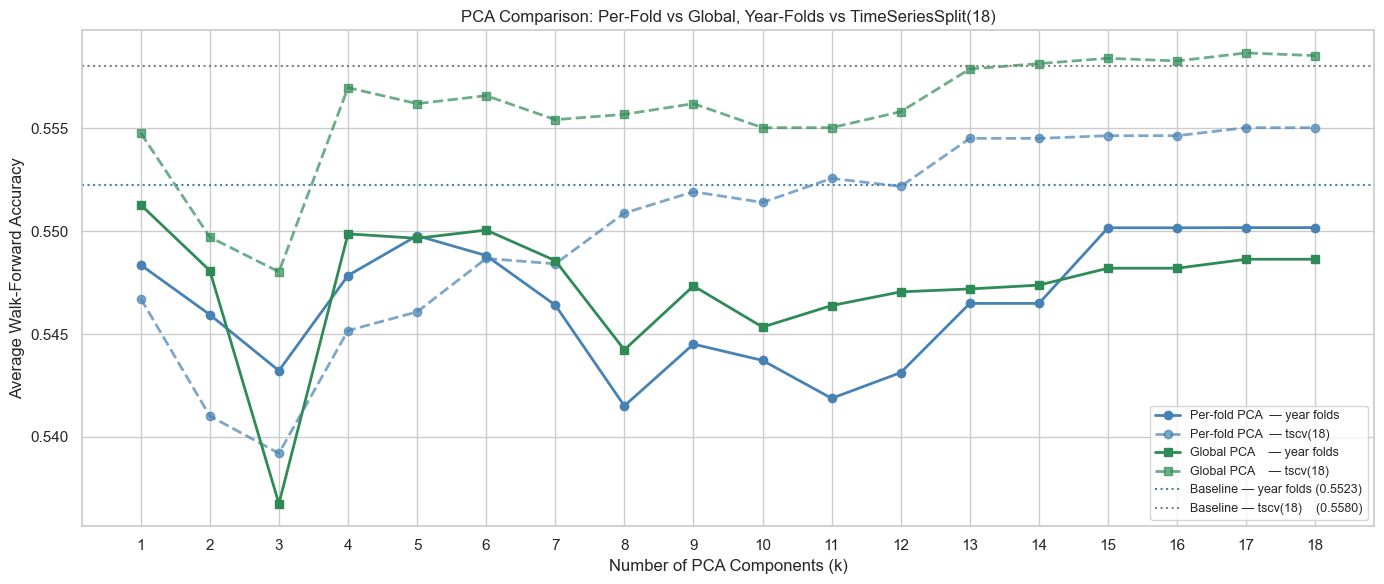

In [94]:
ks = list(range(1, len(FEATURES) + 1))

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(ks, [pca_year[k][0]    for k in ks], 'o-',  color='steelblue', linewidth=2,
        label='Per-fold PCA  — year folds')
ax.plot(ks, [pca_tscv[k][0]    for k in ks], 'o--', color='steelblue', linewidth=2,
        label='Per-fold PCA  — tscv(18)', alpha=0.7)
ax.plot(ks, [global_year[k][0] for k in ks], 's-',  color='seagreen',  linewidth=2,
        label='Global PCA    — year folds')
ax.plot(ks, [global_tscv[k][0] for k in ks], 's--', color='seagreen',  linewidth=2,
        label='Global PCA    — tscv(18)', alpha=0.7)

ax.axhline(bl_acc_year, color='steelblue', linestyle=':', linewidth=1.5,
           label=f'Baseline — year folds ({bl_acc_year:.4f})')
ax.axhline(bl_acc_tscv, color='grey',      linestyle=':', linewidth=1.5,
           label=f'Baseline — tscv(18)    ({bl_acc_tscv:.4f})')

ax.set_xlabel('Number of PCA Components (k)')
ax.set_ylabel('Average Walk-Forward Accuracy')
ax.set_title('PCA Comparison: Per-Fold vs Global, Year-Folds vs TimeSeriesSplit(18)')
ax.set_xticks(ks)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 9. 2D Projection Visualisation

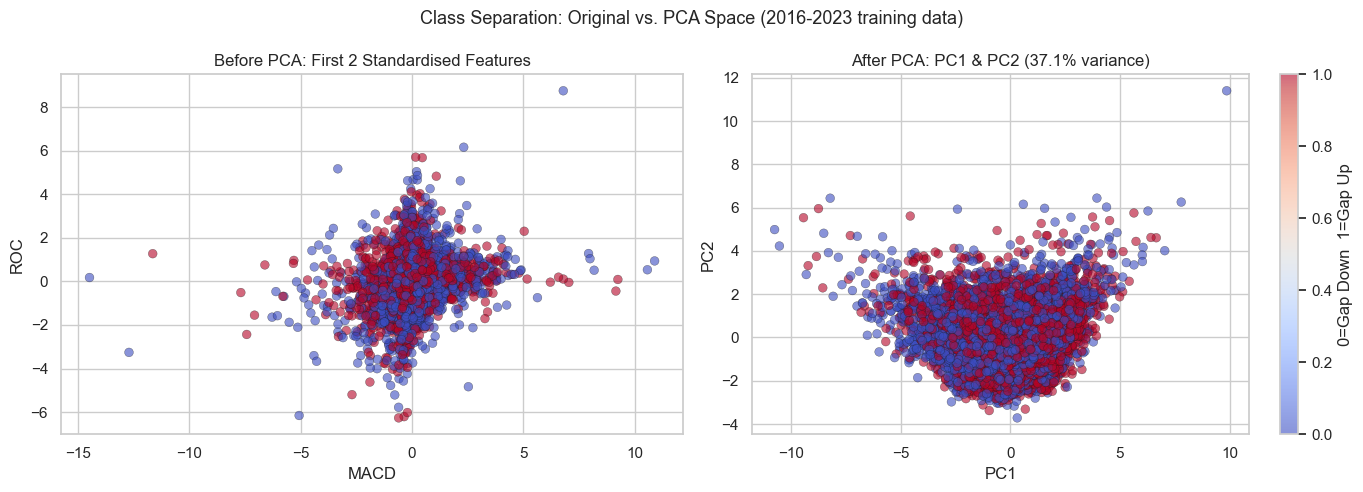

In [95]:
X_vis_2d = PCA(n_components=2).fit_transform(X_vis_tr)
y_vis    = y_all.iloc[last_tr_yr].values
scatter_kws = dict(cmap='coolwarm', edgecolor='k', s=40, alpha=0.6, linewidths=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_vis_tr[:, 0], X_vis_tr[:, 1], c=y_vis, **scatter_kws)
axes[0].set_xlabel(FEATURES[0]); axes[0].set_ylabel(FEATURES[1])
axes[0].set_title('Before PCA: First 2 Standardised Features')

sc = axes[1].scatter(X_vis_2d[:, 0], X_vis_2d[:, 1], c=y_vis, **scatter_kws)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
var_2 = pca_full.explained_variance_ratio_[:2].sum()
axes[1].set_title(f'After PCA: PC1 & PC2 ({var_2:.1%} variance)')

plt.colorbar(sc, ax=axes[1], label='0=Gap Down  1=Gap Up')
plt.suptitle('Class Separation: Original vs. PCA Space (2016-2023 training data)', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Confusion Matrix — Best Per-Fold PCA (Year Folds, Last Fold)

Best k from year-based per-fold sweep, evaluated on the last fold (train 2016–2023, test 2024).

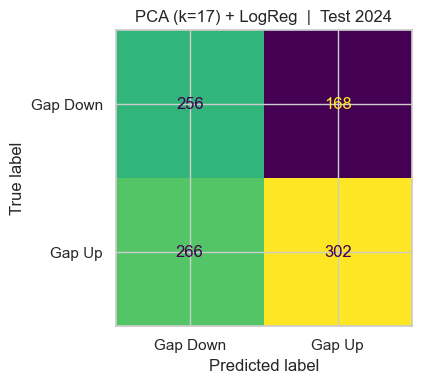

In [96]:
last_tr_yr, last_te_yr = year_folds[-1]
X_tr_s, X_te_s = preprocess(
    X_all.iloc[last_tr_yr], X_all.iloc[last_te_yr],
    tickers_all.iloc[last_tr_yr], tickers_all.iloc[last_te_yr]
)
pca_best    = PCA(n_components=best_k_year)
X_tr_pca    = pca_best.fit_transform(X_tr_s)
X_te_pca    = pca_best.transform(X_te_s)
model_best  = LogisticRegression(
    penalty='l1', solver='liblinear', C=0.05, max_iter=1000, random_state=42
)
model_best.fit(X_tr_pca, y_all.iloc[last_tr_yr])
y_pred_best = model_best.predict(X_te_pca)

cm = confusion_matrix(y_all.iloc[last_te_yr], y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Gap Down', 'Gap Up']).plot(ax=ax, colorbar=False)
ax.set_title(f'PCA (k={best_k_year}) + LogReg  |  Test 2024')
plt.tight_layout()
plt.show()

## 11. XGBoost with PCA — Year Folds

Compares XGBoost with and without PCA using the same setup as `xgboost_model.ipynb`:
- Inner val = last year of training window (same fold structure)
- `eval_metric = 'auc'` — consistent with primary metric
- Fixed params: `n_estimators=500, learning_rate=0.05, early_stopping_rounds=30`

The same params are used with and without PCA — any AUC difference is attributable to PCA alone.

In [97]:
xgb_results = {}

for use_pca, label in [(False, 'XGBoost (no PCA)'), (True, f'XGBoost + PCA (k={best_k_year})')]:
    fold_accs, fold_aucs = [], []
    for fold in FOLDS_DEF:
        train_years = fold['train_years']
        test_year   = fold['test_year']
        val_year    = train_years[-1]
        inner_train = [y for y in train_years if y != val_year]

        tr_idx  = np.where(primary['Year'].isin(train_years))[0]
        te_idx  = np.where(primary['Year'] == test_year)[0]
        itr_idx = np.where(primary['Year'].isin(inner_train))[0]
        iv_idx  = np.where(primary['Year'] == val_year)[0]

        X_tr_s, X_te_s   = preprocess(X_all.iloc[tr_idx],  X_all.iloc[te_idx],
                                       tickers_all.iloc[tr_idx],  tickers_all.iloc[te_idx])
        X_itr_s, X_iv_s  = preprocess(X_all.iloc[itr_idx], X_all.iloc[iv_idx],
                                       tickers_all.iloc[itr_idx], tickers_all.iloc[iv_idx])

        if use_pca:
            pca      = PCA(n_components=best_k_year)
            X_tr_s   = pca.fit_transform(X_tr_s)
            X_te_s   = pca.transform(X_te_s)
            X_itr_s  = pca.fit_transform(X_itr_s)
            X_iv_s   = pca.transform(X_iv_s)

        xgb = XGBClassifier(
            n_estimators=500, learning_rate=0.05, early_stopping_rounds=30,
            random_state=42, eval_metric='auc', verbosity=0
        )
        xgb.fit(X_itr_s, y_all.iloc[itr_idx].values,
                eval_set=[(X_iv_s, y_all.iloc[iv_idx].values)],
                verbose=False)

        y_pred = xgb.predict(X_te_s)
        y_prob = xgb.predict_proba(X_te_s)[:, 1]
        fold_accs.append(accuracy_score(y_all.iloc[te_idx], y_pred))
        fold_aucs.append(roc_auc_score(y_all.iloc[te_idx], y_prob))

    xgb_results[label] = {'acc': np.mean(fold_accs), 'auc': np.mean(fold_aucs)}
    print(f'{label:40s}  Acc={np.mean(fold_accs):.4f}  AUC={np.mean(fold_aucs):.4f}')

XGBoost (no PCA)                          Acc=0.5381  AUC=0.5550
XGBoost + PCA (k=17)                      Acc=0.5159  AUC=0.5360


## 12. Summary

In [98]:
print('=' * 70)
print('PCA EXPERIMENT — RESULTS SUMMARY')
print('=' * 70)
print(f'Features: {len(FEATURES)}  |  Rows: {len(X_all):,}  |  Date range: '
      f'{dates_all.min().date()} to {dates_all.max().date()}')
print(f'Note: year-fold averages exclude COVID fold (test 2020), matching logistic_regression.ipynb')
print()
rows = [
    ('Baseline (LogReg)',               'Year folds',      bl_acc_year,                   bl_auc_year,                   '-'),
    ('Baseline (LogReg)',               'tscv(18)',         bl_acc_tscv,                   bl_auc_tscv,                   '-'),
    (f'Per-fold PCA k={best_k_year}',  'Year folds',      pca_year[best_k_year][0],      pca_year[best_k_year][1],      f'{(pca_year[best_k_year][0]-bl_acc_year)/bl_acc_year*100:+.2f}%'),
    (f'Per-fold PCA k={best_k_tscv}',  'tscv(18)',         pca_tscv[best_k_tscv][0],     pca_tscv[best_k_tscv][1],     f'{(pca_tscv[best_k_tscv][0]-bl_acc_tscv)/bl_acc_tscv*100:+.2f}%'),
    (f'Global PCA k={best_kg_year}',   'Year folds',      global_year[best_kg_year][0],  global_year[best_kg_year][1],  f'{(global_year[best_kg_year][0]-bl_acc_year)/bl_acc_year*100:+.2f}%'),
    (f'Global PCA k={best_kg_tscv}',   'tscv(18)',         global_tscv[best_kg_tscv][0], global_tscv[best_kg_tscv][1], f'{(global_tscv[best_kg_tscv][0]-bl_acc_tscv)/bl_acc_tscv*100:+.2f}%'),
]
print(f'{"Method":<30} {"Folds":<14} {"Avg Acc":>8}  {"Avg AUC":>8}  {"vs Baseline":>12}')
print('-' * 76)
for method, folds, acc, auc, diff in rows:
    auc_str = f'{auc:.4f}' if isinstance(auc, float) else '—'
    print(f'{method:<30} {folds:<14} {acc:8.4f}  {auc_str:>8}  {diff:>12}')
print()
print(f'Variance retained: 90% at k={n_90}, 95% at k={n_95}')
print()
print(f'{"XGBoost (year folds)":<40}  {"Acc":>8}  {"AUC":>8}')
print('-' * 60)
for lbl, res in xgb_results.items():
    print(f'{lbl:<40}  {res["acc"]:8.4f}  {res["auc"]:8.4f}')
print('=' * 70)

PCA EXPERIMENT — RESULTS SUMMARY
Features: 18  |  Rows: 8,146  |  Date range: 2016-04-18 to 2024-12-23
Note: year-fold averages exclude COVID fold (test 2020), matching logistic_regression.ipynb

Method                         Folds           Avg Acc   Avg AUC   vs Baseline
----------------------------------------------------------------------------
Baseline (LogReg)              Year folds       0.5523    0.5736             -
Baseline (LogReg)              tscv(18)         0.5580    0.5786             -
Per-fold PCA k=17              Year folds       0.5502    0.5666        -0.38%
Per-fold PCA k=17              tscv(18)         0.5550    0.5730        -0.54%
Global PCA k=1                 Year folds       0.5513    0.5598        -0.18%
Global PCA k=17                tscv(18)         0.5587    0.5751        +0.12%

Variance retained: 90% at k=11, 95% at k=13

XGBoost (year folds)                           Acc       AUC
------------------------------------------------------------
XGBoos